# Tarea 6 — Segmentación de clientes

**Dataset:** `Customers.csv` — Mall Customer Segmentation (Kaggle)
**Algoritmos:** K-Means y Clustering Jerárquico Aglomerativo
**Curso:** Minería de Datos · Lead University

## 1. Librerías

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from scripts.clustering_jerarquico_utils import (
    centroide,
    matriz_distancias,
    agregaciones,
    plot_dendrograma,
    plot_dendrograma_cortes,
    altura_corte,
    etiquetas_jerarquicas,
    centros_clusters,
)

from scripts.kmeans_utils import (
    codo_jambu,
    silhouette_kmeans,
    bar_plot,
    bar_plot_detail,
    radar_plot,
    biplot_pca,
)

sns.set_theme(style='whitegrid', palette='Set2')
SEED = 42

## 2. Carga y exploración inicial de los datos

In [56]:
df = pd.read_csv('datos/Customers.csv')
print(f'Forma del dataset: {df.shape}')
df.head()

Forma del dataset: (2000, 8)


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


In [57]:
df.info()
print('\nValores nulos por columna:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              2000 non-null   int64 
 1   Gender                  2000 non-null   object
 2   Age                     2000 non-null   int64 
 3   Annual Income ($)       2000 non-null   int64 
 4   Spending Score (1-100)  2000 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience         2000 non-null   int64 
 7   Family Size             2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB

Valores nulos por columna:
CustomerID                 0
Gender                     0
Age                        0
Annual Income ($)          0
Spending Score (1-100)     0
Profession                35
Work Experience            0
Family Size                0
dtype: int64


In [58]:
df.describe()

,CustomerID,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,48.960000,110731.821500,50.962500,4.102500,3.768500
std,577.494589,28.429747,45739.536688,27.934661,3.922204,1.970749
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,500.750000,25.000000,74572.000000,28.000000,1.000000,2.000000
50%,1000.500000,48.000000,110045.000000,50.000000,3.000000,4.000000
75%,1500.250000,73.000000,149092.750000,75.000000,7.000000,5.000000
max,2000.000000,99.000000,189974.000000,100.000000,17.000000,9.000000


### Interpretación

El dataset contiene **2000 clientes** de un centro comercial con 8 columnas. Para el análisis de
distancias sirven las cinco variables numéricas: `Age`, `Annual Income ($)`, `Spending Score (1-100)`,
`Work Experience` y `Family Size`. Se descartan `CustomerID` (identificador sin significado métrico),
`Gender` y `Profession` (categóricas, no aptas para la distancia euclídea).

Los únicos nulos están en `Profession` (35 registros), que no se usa. Llama la atención que `Age` y
`Annual Income ($)` tengan **mínimo 0**: hay clientes con edad e ingreso registrados en cero, lo que
apunta a datos faltantes codificados como 0 más que a valores reales. Las escalas son muy dispares
—el ingreso llega a 189 974 mientras el tamaño familiar va de 1 a 9—, así que la estandarización es
imprescindible.

## 3. Preprocesamiento

Punto 2 del enunciado: limpieza básica (valores nulos y atípicos) y **estandarización obligatoria**
de las variables numéricas para que las escalas no sesguen las distancias.

In [59]:
# Variables numéricas relevantes para la segmentación
FEATURES = ['Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Work Experience', 'Family Size']
df_num = df[FEATURES].copy()

# Limpieza básica: imputación de nulos por la mediana
print('Nulos antes de imputar:', df_num.isnull().sum().sum())
df_num = df_num.fillna(df_num.median())

# Limpieza básica: valores atípicos extremos por el criterio del rango interquartílico
Q1, Q3 = df_num.quantile(0.25), df_num.quantile(0.75)
IQR = Q3 - Q1
mask_outliers = ((df_num < (Q1 - 3 * IQR)) | (df_num > (Q3 + 3 * IQR))).any(axis=1)
print(f'Atípicos extremos detectados (3×IQR): {mask_outliers.sum()} filas')

df_num = df_num[~mask_outliers].reset_index(drop=True)
print(f'Registros tras la limpieza: {len(df_num)}')

Nulos antes de imputar: 0
Atípicos extremos detectados (3×IQR): 0 filas
Registros tras la limpieza: 2000


In [60]:
# Estandarización obligatoria (media 0, desviación estándar 1)
scaler = StandardScaler()
X = scaler.fit_transform(df_num)

print('Tras estandarizar:')
print('  Media:', X.mean(axis=0).round(4))
print('  Std:  ', X.std(axis=0).round(4))

Tras estandarizar:
  Media: [-0. -0.  0. -0.  0.]
  Std:   [1. 1. 1. 1. 1.]


### Interpretación

Tras la selección de variables no queda ningún nulo por imputar y el criterio de 3×IQR **no detecta
ningún atípico extremo**: las cinco variables tienen rangos acotados y distribuciones sin colas
largas, por lo que los 2000 registros se conservan íntegros.

La estandarización deja todas las columnas con media 0 y desviación estándar 1. Sin este paso, el
ingreso anual (escala de cientos de miles) dominaría por completo la distancia euclídea y el tamaño
familiar (escala 1–9) sería prácticamente invisible para los algoritmos.

## 4. Determinación del número óptimo de clusters (K)

Punto 3 del enunciado: **Método del Codo de Jambú**, evaluando la inercia (WCSS) para k de 1 a 10.
Se acompaña del método de la silueta, también definido en el notebook de Clase 8.

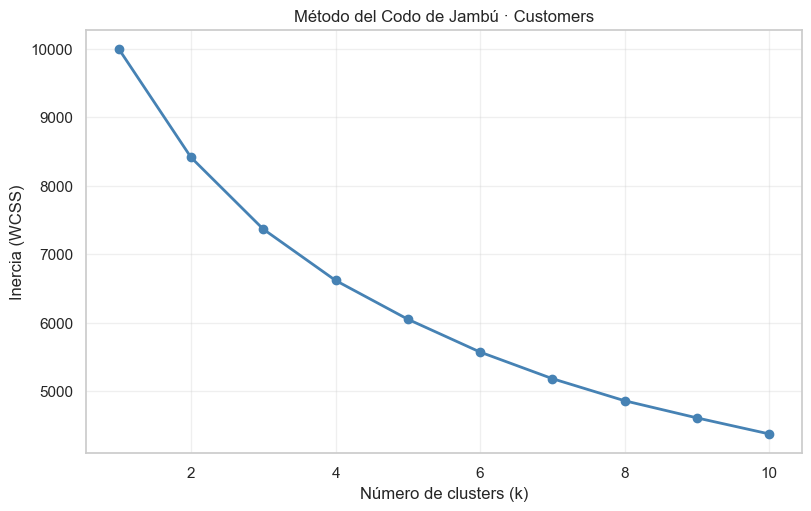

In [61]:
# Método del Codo de Jambú — función codo_jambu del notebook Clase 8 - Kmeans.ipynb
fig = codo_jambu(X, max_k=10)
plt.title('Método del Codo de Jambú · Customers')
plt.show()

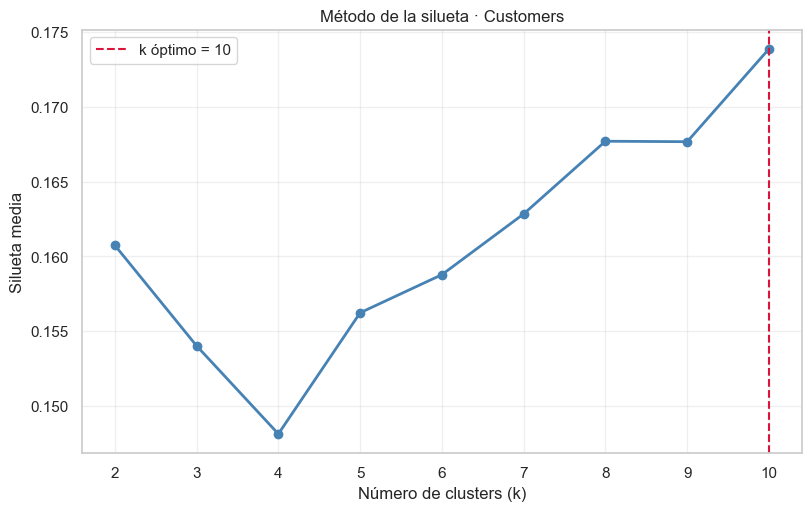

K con silueta máxima            : 10
K óptimo adoptado (codo de Jambú): 4


In [62]:
# Método de la silueta — función silhouette_kmeans del notebook Clase 8 - Kmeans.ipynb
fig, K_AUTO = silhouette_kmeans(X, max_k=10)
plt.title('Método de la silueta · Customers')
plt.show()

# El máximo estadístico de la silueta no siempre es el K accionable para negocio:
# se adopta el codo visual, que produce segmentos interpretables.
K_OPT = 4
print(f'K con silueta máxima            : {K_AUTO}')
print(f'K óptimo adoptado (codo de Jambú): {K_OPT}')

### Interpretación

La curva del codo de Jambú **desciende de forma suave y continua**, sin un quiebre marcado: es el
comportamiento típico de variables demográficas continuas donde no existen grupos naturalmente
separados. El codo visual más razonable se ubica alrededor de **k = 4**.

El método de la silueta señala su máximo en **k = 10**, el extremo del rango evaluado. Ese máximo no
indica una estructura real: al no haber grupos separados, la silueta premia particiones cada vez más
finas. Además, diez segmentos no son accionables para una estrategia comercial. Se adopta por tanto
**K = 4**, el codo visual, que produce segmentos con volumen y perfil distinguibles.

## 5. K-Means con el K óptimo

In [63]:
# K-Means — bloques 8 a 10 del notebook Clase 8 - Kmeans.ipynb
kmedias = KMeans(n_clusters=K_OPT, random_state=SEED, n_init=20)
kmedias.fit(X)

etiquetas = kmedias.predict(X)
print('Grupos\n', etiquetas)

print('\nTamaño de cada cluster:')
print(pd.Series(etiquetas).value_counts().sort_index())

Grupos
 [2 1 2 ... 0 0 2]

Tamaño de cada cluster:
0    490
1    491
2    468
3    551
Name: count, dtype: int64


In [64]:
# Centros de cada cluster — bloque 10 del notebook de clase
# Se devuelven a la escala original con el scaler para poder interpretarlos.
centros = np.array(kmedias.cluster_centers_)
centros_orig = scaler.inverse_transform(centros)

print('Centros (escala original)\n')
print(pd.DataFrame(centros_orig, columns=FEATURES,
                   index=[f'Cluster {c}' for c in range(K_OPT)]).round(2))

Centros (escala original)

             Age  Annual Income ($)  Spending Score (1-100)  Work Experience  \
Cluster 0  49.38          120144.14                   47.46             9.20   
Cluster 1  42.75           98196.62                   79.98             2.18   
Cluster 2  51.65           95279.62                   26.69             1.68   
Cluster 3  51.84          126599.44                   48.79             3.34   

           Family Size  
Cluster 0         3.14  
Cluster 1         2.85  
Cluster 2         2.58  
Cluster 3         6.15  


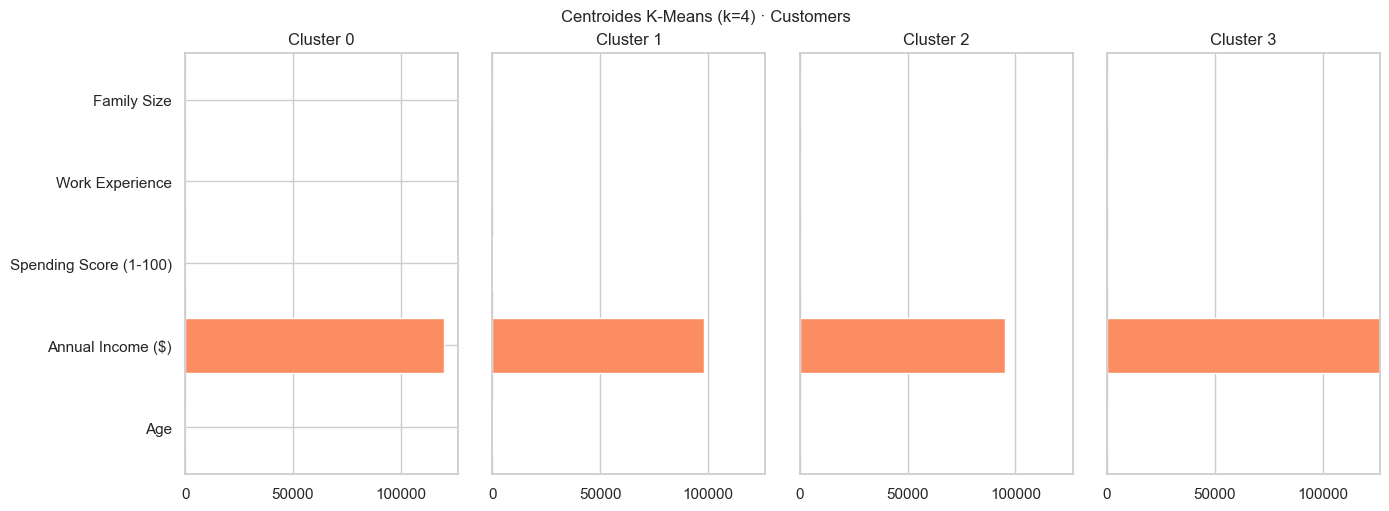

In [65]:
# Visualizar los centros con bar_plot — bloque 11 del notebook de clase
fig = bar_plot(centros_orig, list(FEATURES), figsize=(14, 5))
plt.suptitle(f'Centroides K-Means (k={K_OPT}) · Customers', fontsize=12)
plt.show()

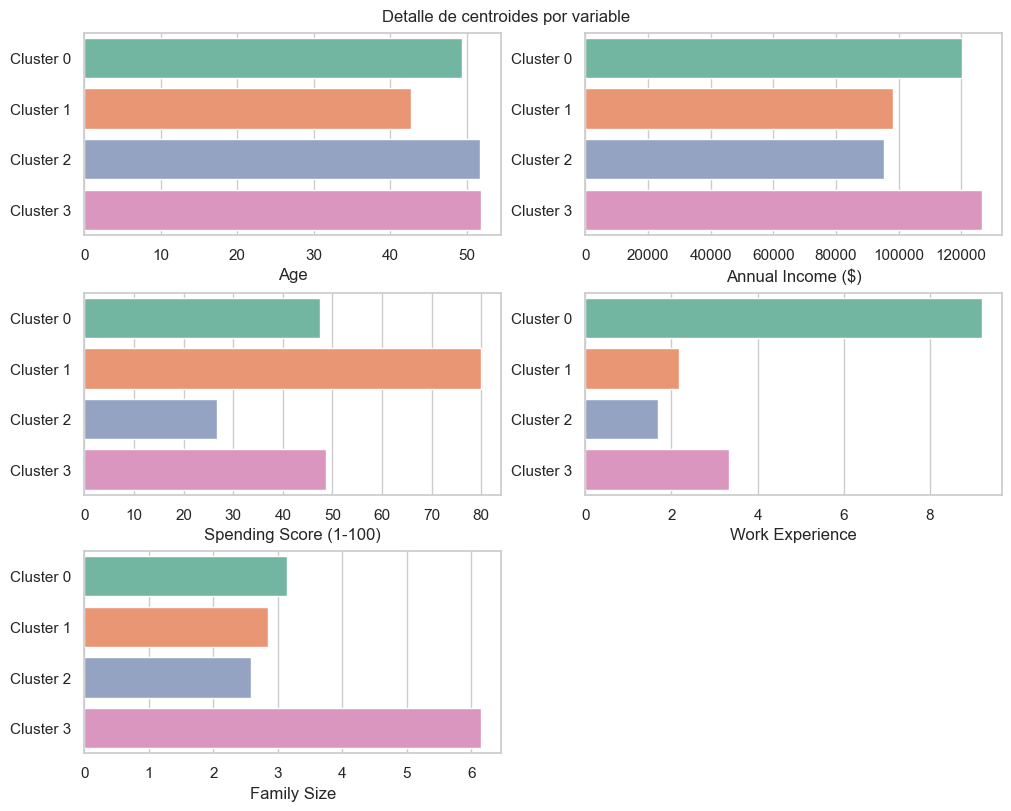

In [66]:
# Detalle por variable: un panel por variable comparando todos los clusters
# (función bar_plot_detail del notebook Clase 8 - Kmeans.ipynb)
fig = bar_plot_detail(centros_orig, list(FEATURES), figsize=(10, 8))
plt.show()

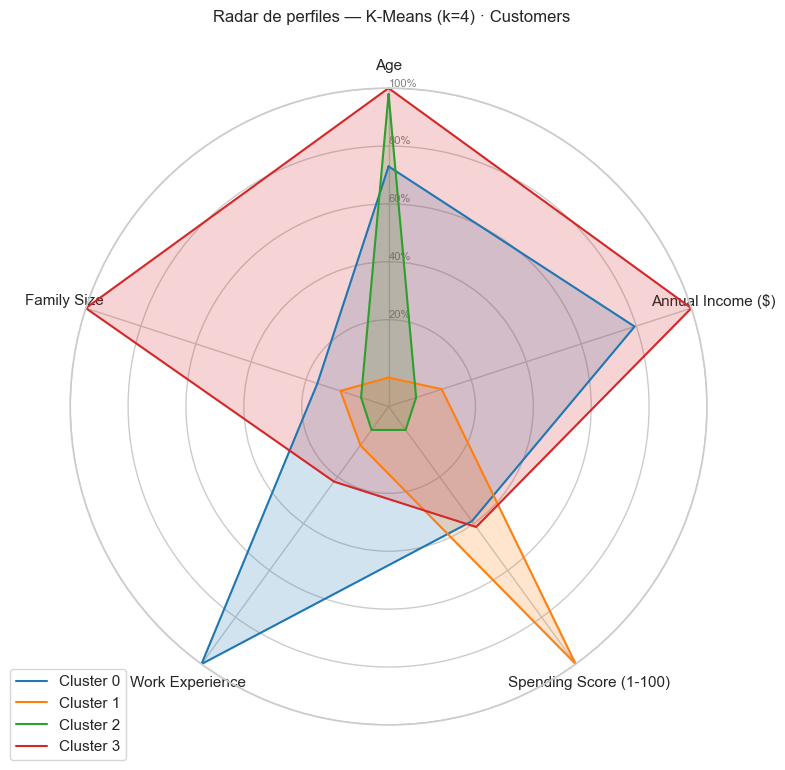

In [67]:
# Visualizar los centros con gráfico de radar — bloque 12 del notebook de clase
fig = radar_plot(centros_orig, list(FEATURES))
plt.suptitle(f'Radar de perfiles — K-Means (k={K_OPT}) · Customers', fontsize=12)
plt.show()

### Interpretación

Con k = 4, K-Means genera cuatro grupos de tamaño muy equilibrado (468 a 551 clientes) y, en escala
original, cuatro arquetipos claramente diferenciados:

| Cluster | n | Edad | Ingreso | Gasto | Experiencia | Familia | Perfil |
|---|---|---|---|---|---|---|---|
| 0 | 490 | 49.4 | 120 144 | 47.5 | **9.2** | 3.1 | Trayectoria laboral larga, gasto medio |
| 1 | 491 | 42.8 | 98 197 | **80.0** | 2.2 | 2.9 | **Alto gasto**, ingreso medio, más jóvenes |
| 2 | 468 | 51.7 | 95 280 | **26.7** | 1.7 | 2.6 | **Bajo gasto**, ingreso más bajo |
| 3 | 551 | 51.8 | **126 599** | 48.8 | 3.3 | **6.2** | Ingreso alto y **familia numerosa** |

Las variables que realmente separan los grupos son el **Spending Score** (26.7 a 80.0), el **tamaño
familiar** (2.6 a 6.2) y la **experiencia laboral** (1.7 a 9.2). La edad, en cambio, es casi idéntica
en tres de los cuatro clusters (49–52 años), por lo que aporta poco a la segmentación.

El radar confirma que ningún cluster domina todas las dimensiones: cada uno destaca en una o dos
variables, lo que es señal de segmentos complementarios y no de una simple gradación de "mejor a peor
cliente".

## 6. Clustering Jerárquico Aglomerativo

Se sigue el procedimiento del notebook de clase `Clase 7 - Clustering jerarquico.ipynb`:

1. Calcular la **matriz de distancias** euclídeas con `pdist`.
2. Calcular las **agregaciones** con los cuatro métodos de vinculación: Ward, Average, Single y Complete.
3. Dibujar el **dendrograma** de cada método para compararlos visualmente.
4. Trazar **líneas horizontales** sobre el dendrograma de Ward para validar el corte del número de clusters.
5. Obtener las etiquetas con `fcluster(..., criterion='maxclust') - 1`.
6. Calcular los **centros** de cada cluster con `centroide` e interpretarlos con `bar_plot` y `radar_plot`.

In [68]:
# Matriz de distancias euclídeas — bloque 7 del notebook de clase
dist = matriz_distancias(X, metric='euclidean')

print(f'Vector condensado de distancias: {dist.shape[0]} pares  (= n(n-1)/2 con n = {X.shape[0]})')
print(f'Distancia mínima: {dist.min():.4f}  |  máxima: {dist.max():.4f}  |  media: {dist.mean():.4f}')

Vector condensado de distancias: 1999000 pares  (= n(n-1)/2 con n = 2000)
Distancia mínima: 0.0548  |  máxima: 6.9525  |  media: 3.0368


In [69]:
# Agregaciones con los 4 métodos de vinculación — bloque 10 del notebook de clase
ward_res, average_res, single_res, complete_res = agregaciones(X)

# Cada fila de la matriz de enlaces indica qué dos clusters se unen,
# a qué distancia se unieron y cuántos elementos quedan en el nuevo cluster.
print('Matriz de enlaces de Ward — últimas 5 fusiones (las de mayor altura):')
print(pd.DataFrame(ward_res[-5:], columns=['cluster_1', 'cluster_2', 'distancia', 'n_elementos']).round(3))

Matriz de enlaces de Ward — últimas 5 fusiones (las de mayor altura):
   cluster_1  cluster_2  distancia  n_elementos
0     3987.0     3989.0     30.729        453.0
1     3986.0     3994.0     31.703        704.0
2     3988.0     3993.0     33.365        773.0
3     3992.0     3996.0     44.402       1296.0
4     3995.0     3997.0     44.867       2000.0


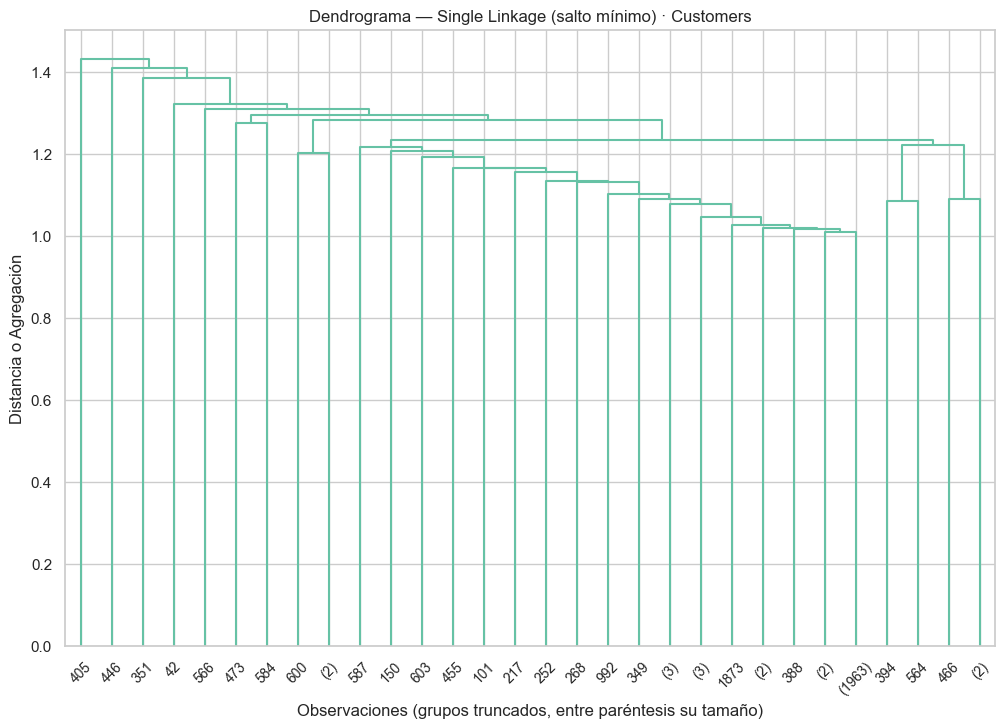

In [70]:
# Dendrograma con Single Linkage (salto mínimo) — bloque 11 del notebook de clase
fig = plot_dendrograma(single_res, truncate_mode='lastp', p=30,
                       titulo='Dendrograma — Single Linkage (salto mínimo) · Customers')
plt.show()

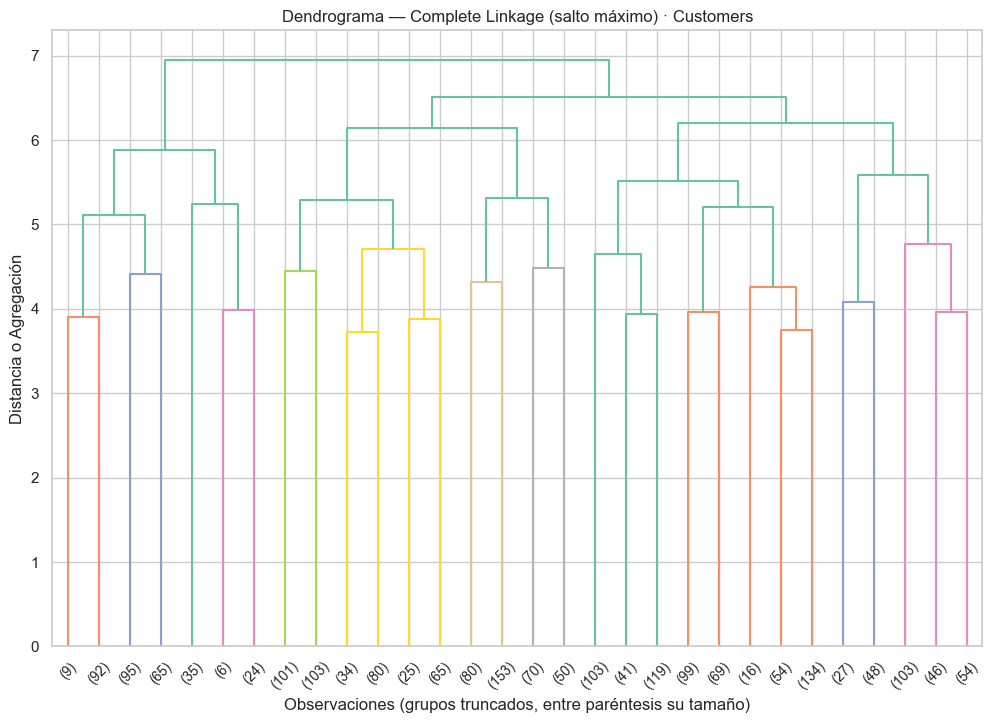

In [71]:
# Dendrograma con Complete Linkage (salto máximo) — bloque 12 del notebook de clase
fig = plot_dendrograma(complete_res, truncate_mode='lastp', p=30,
                       titulo='Dendrograma — Complete Linkage (salto máximo) · Customers')
plt.show()

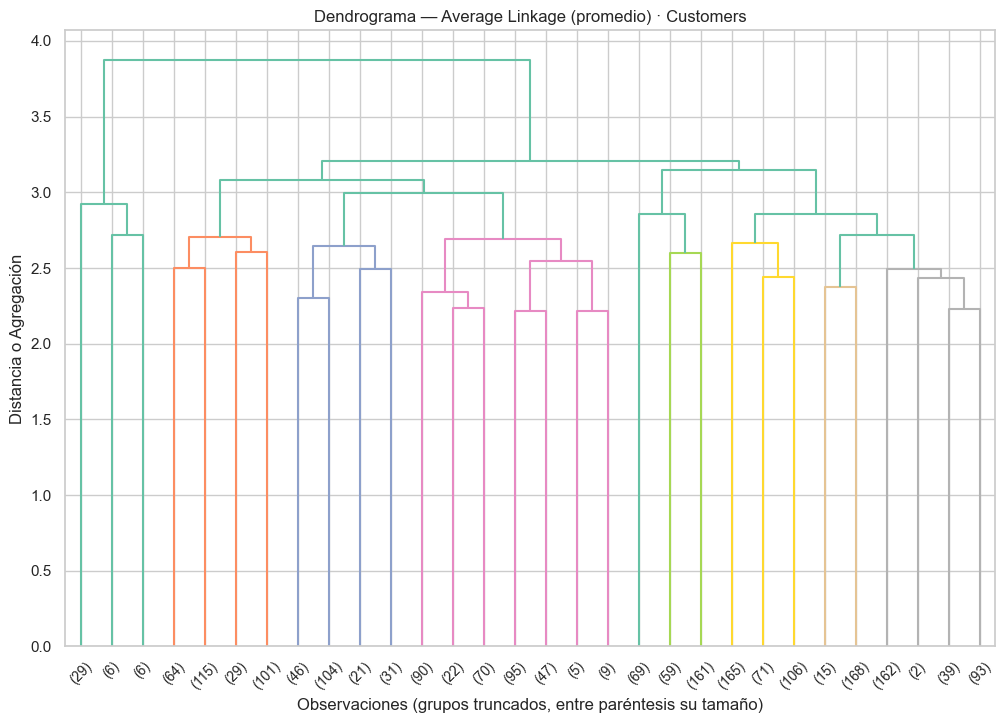

In [72]:
# Dendrograma con Average Linkage (promedio) — bloque 13 del notebook de clase
fig = plot_dendrograma(average_res, truncate_mode='lastp', p=30,
                       titulo='Dendrograma — Average Linkage (promedio) · Customers')
plt.show()

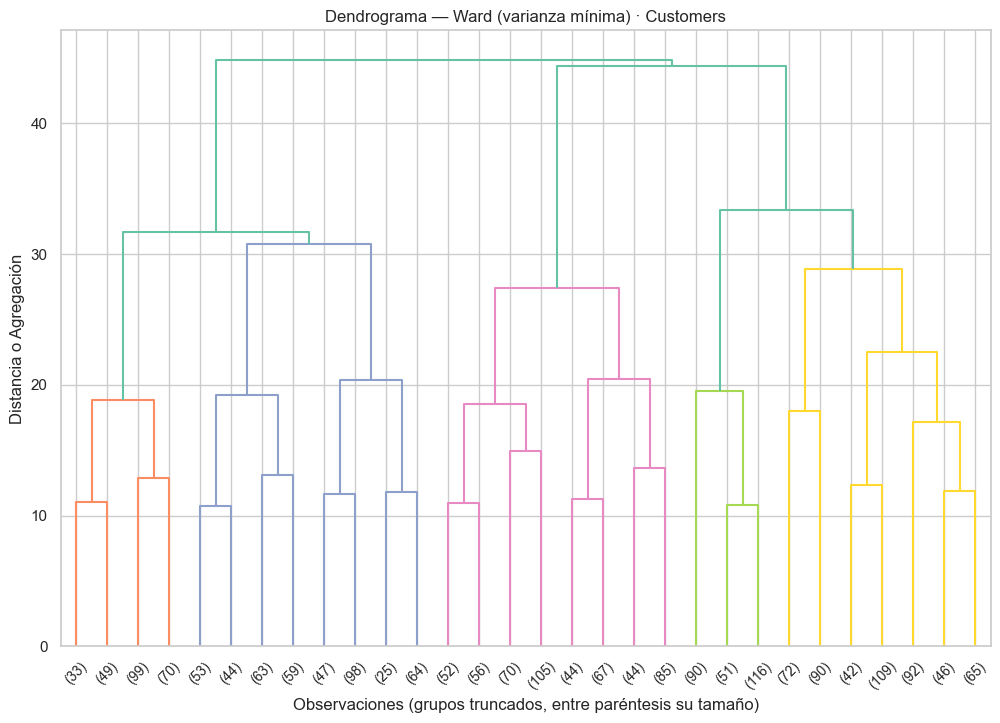

In [73]:
# Dendrograma con Ward — bloque 14 del notebook de clase
fig = plot_dendrograma(ward_res, truncate_mode='lastp', p=30,
                       titulo='Dendrograma — Ward (varianza mínima) · Customers')
plt.show()

### Interpretación

Con 2000 clientes el dendrograma completo sería ilegible, por lo que se truncan los últimos 30 grupos
(`truncate_mode='lastp'`); los números entre paréntesis indican cuántas observaciones contiene cada
hoja agregada.

La comparación entre métodos reproduce lo que describe el notebook de clase:

- **Single** muestra el **efecto cadena** de forma extrema: las fusiones se encadenan casi todas a
  alturas bajas y muy similares, formando un árbol muy asimétrico. Es el método menos útil aquí.
- **Complete** produce un árbol más equilibrado, con grupos compactos y de tamaño parecido.
- **Average** queda en un punto medio, con una estructura intermedia entre los dos anteriores.
- **Ward** es el que ofrece la separación más nítida: las ramas principales se fusionan a alturas
  claramente superiores al resto, lo que facilita elegir dónde cortar.

Por eso se usa **Ward** para el corte, tal como hace el notebook de clase.

### Validar el corte del número de clusters

Se trazan **líneas horizontales** sobre el dendrograma de Ward: el número de clusters es igual a la
cantidad de ramas verticales que cruza la línea. Se comparan el corte en k = {K_OPT} (el K óptimo de
K-Means) con los cortes vecinos, buscando un **salto vertical grande** entre uniones consecutivas.

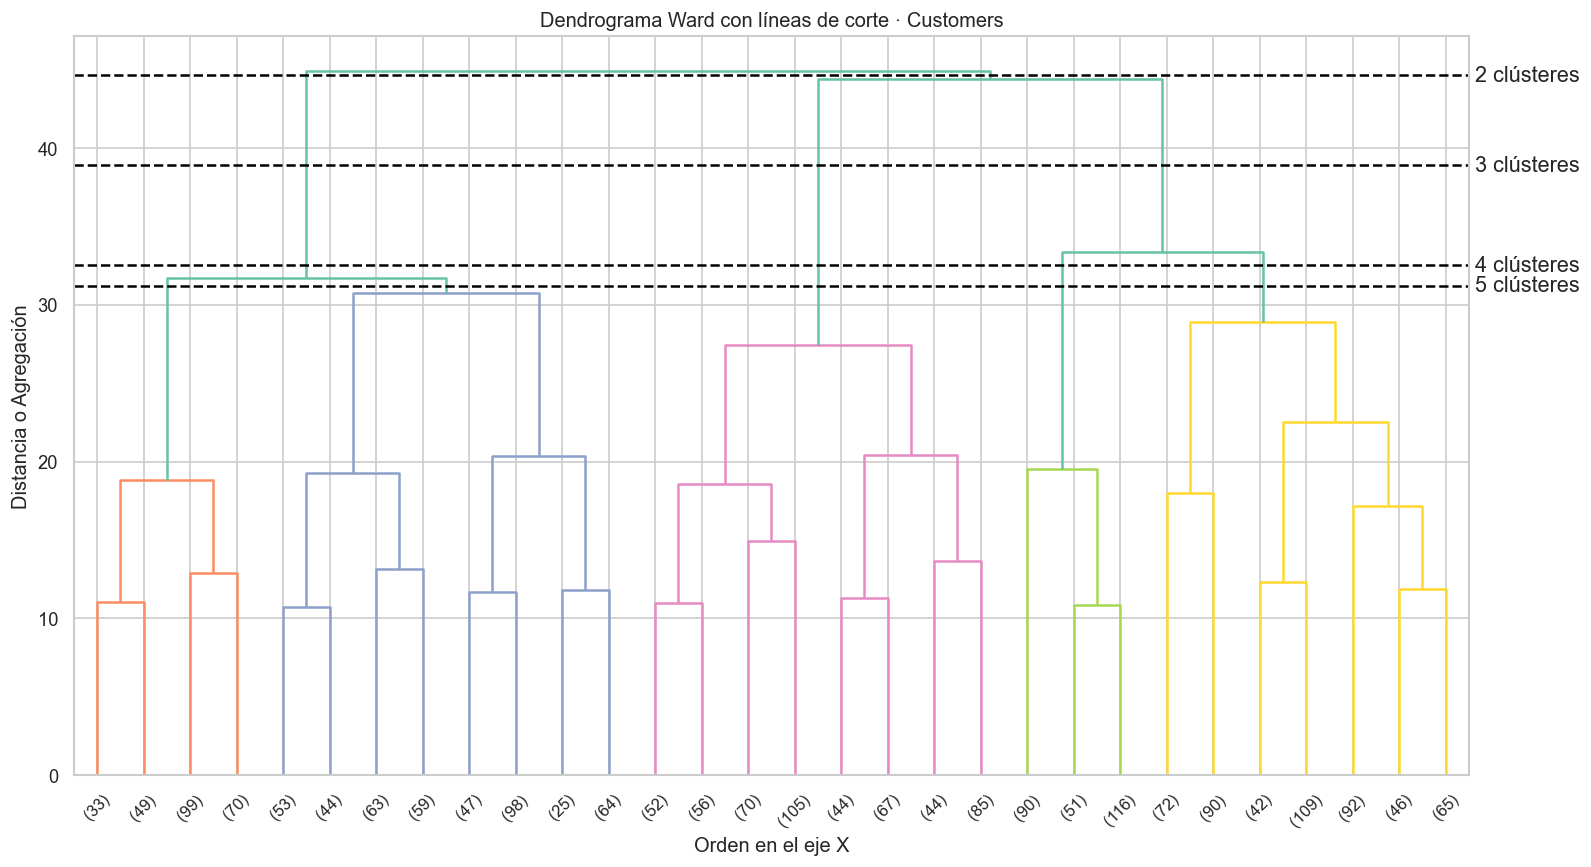

   2 clústeres  →  corte a la altura 44.63
   3 clústeres  →  corte a la altura 38.88
   4 clústeres  →  corte a la altura 32.53
   5 clústeres  →  corte a la altura 31.22


In [74]:
# Líneas de corte sobre el dendrograma de Ward — bloque 15 del notebook de clase
cortes = [(altura_corte(ward_res, k), f'{k} clústeres') for k in (2, 3, K_OPT, K_OPT + 1)]
cortes = sorted(set(cortes), key=lambda t: -t[0])

fig = plot_dendrograma_cortes(ward_res, cortes=cortes, truncate_mode='lastp', p=30,
                              titulo='Dendrograma Ward con líneas de corte · Customers')
plt.show()

for altura, texto in cortes:
    print(f'{texto:>14}  →  corte a la altura {altura:.2f}')

In [75]:
# Etiquetas de cluster jerárquico — bloque 16 del notebook de clase
K_HIER = K_OPT
grupos = etiquetas_jerarquicas(X, K_HIER, method='ward', metric='euclidean')
print('Grupos\n', grupos)

print('\nTamaño de cada cluster jerárquico:')
print(pd.Series(grupos).value_counts().sort_index())

Grupos
 [2 1 2 ... 0 0 0]

Tamaño de cada cluster jerárquico:
0    704
1    523
2    257
3    516
Name: count, dtype: int64


In [76]:
# Centros de cada cluster jerárquico — bloque 17 del notebook de clase
# El clustering jerárquico no produce centros internamente: se calcula el promedio
# de cada variable por cluster con la función centroide().
centros_hier = centros_clusters(df_num, grupos, K_HIER)
print('Centros (escala original)\n')
print(pd.DataFrame(centros_hier, columns=FEATURES,
                   index=[f'Cluster {c}' for c in range(K_HIER)]).round(2))

Centros (escala original)

             Age  Annual Income ($)  Spending Score (1-100)  Work Experience  \
Cluster 0  57.97          125760.18                   41.02             7.06   
Cluster 1  30.58           99747.55                   77.46             4.64   
Cluster 2  41.57           83288.47                   31.35             0.96   
Cluster 3  58.98          115029.78                   47.43             1.09   

           Family Size  
Cluster 0         3.48  
Cluster 1         3.61  
Cluster 2         2.26  
Cluster 3         5.08  


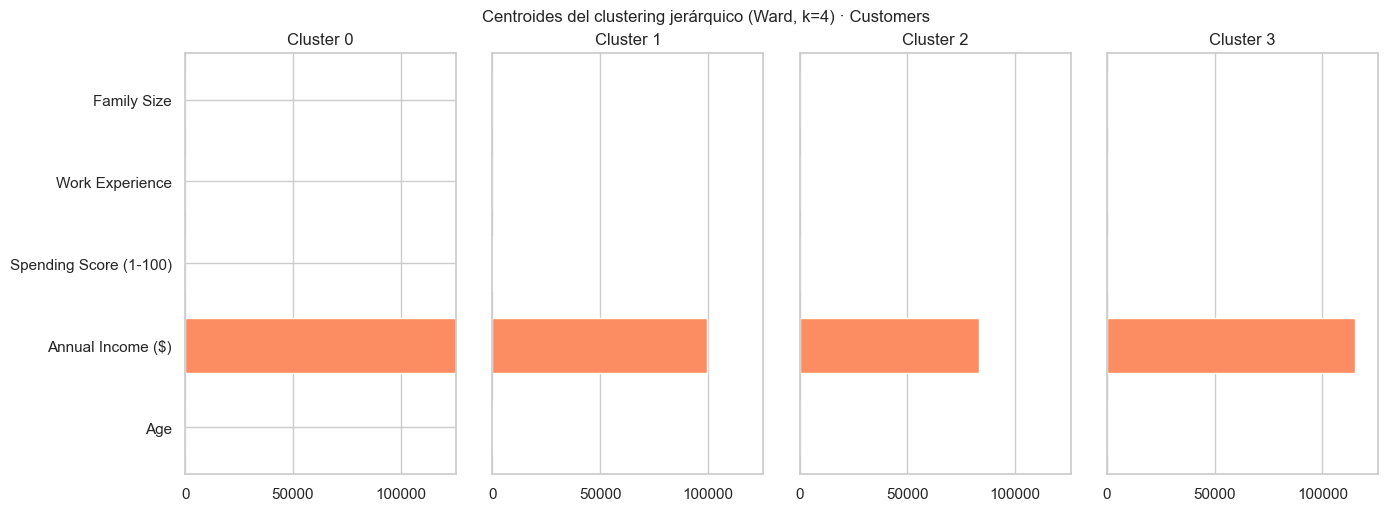

In [77]:
# Interpretación de los centros jerárquicos con bar_plot — bloque 18 del notebook de clase
fig = bar_plot(centros_hier, list(FEATURES), figsize=(14, 5))
plt.suptitle(f'Centroides del clustering jerárquico (Ward, k={K_HIER}) · Customers', fontsize=12)
plt.show()

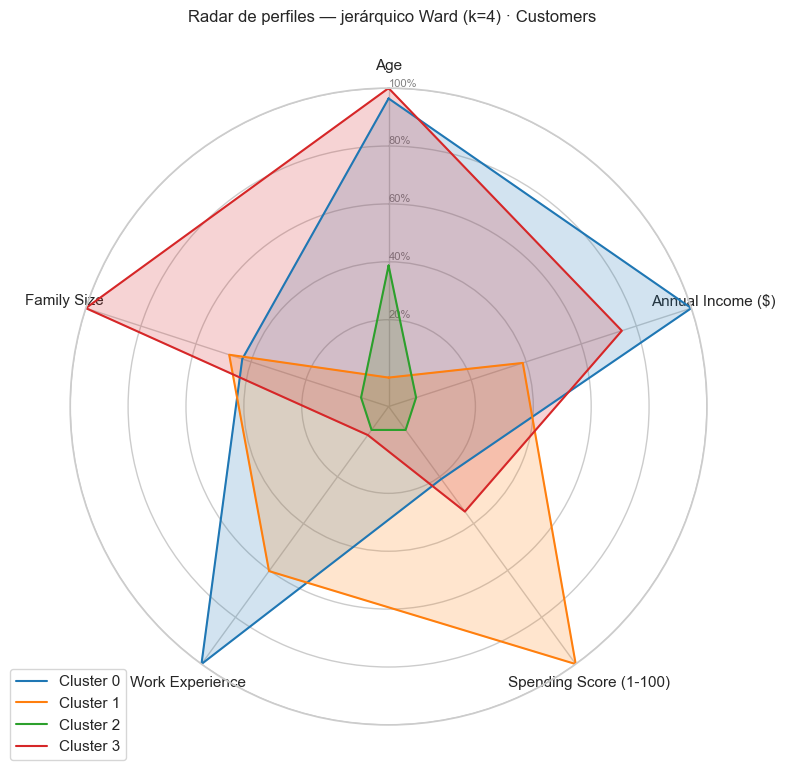

In [78]:
# Interpretación de los centros jerárquicos con radar_plot — bloque 21 del notebook de clase
fig = radar_plot(centros_hier, list(FEATURES))
plt.suptitle(f'Radar de perfiles — jerárquico Ward (k={K_HIER}) · Customers', fontsize=12)
plt.show()

### Interpretación

Las alturas de corte calculadas muestran un **salto grande entre 4 y 3 clusters** (32.53 → 38.88) y
otro entre 3 y 2 (38.88 → 44.63), mientras que pasar de 5 a 4 clusters apenas sube de 31.22 a 32.53.
Esa diferencia respalda cortar en **k = 4**: por debajo de esa altura las fusiones son entre grupos
parecidos, y por encima se empiezan a unir grupos claramente distintos.

Los tamaños que produce Ward son más desiguales que los de K-Means (704, 523, 516 y 257 frente a
468–551), algo esperable: el jerárquico sigue la geometría de los datos en lugar de forzar regiones
de tamaño comparable alrededor de centroides.

Los centros jerárquicos identifican arquetipos parcialmente distintos:

| Cluster | n | Edad | Ingreso | Gasto | Experiencia | Familia |
|---|---|---|---|---|---|---|
| 0 | 704 | 58.0 | 125 760 | 41.0 | **7.1** | 3.5 |
| 1 | 523 | **30.6** | 99 748 | **77.5** | 4.6 | 3.6 |
| 2 | 257 | 41.6 | **83 288** | 31.4 | **1.0** | 2.3 |
| 3 | 516 | 59.0 | 115 030 | 47.4 | 1.1 | **5.1** |

La diferencia más notable respecto a K-Means es que Ward **sí usa la edad** como criterio de
separación: el cluster 1 concentra clientes jóvenes (30.6 años de media) con el gasto más alto,
mientras los clusters 0 y 3 agrupan clientes mayores (58–59 años). K-Means, al buscar regiones
esféricas de varianza similar, había repartido las edades de forma casi uniforme.

## 7. Análisis y conclusiones visuales con PCA

Punto 5 del enunciado: gráficos de dispersión con **componentes principales** (el dataset tiene más de
dos dimensiones) donde se visualizan los clusters asignados por **cada algoritmo**.

In [79]:
# Reducción de dimensiones con PCA — bloques 13 y 14 del notebook Clase 8 - Kmeans.ipynb
pca = PCA(n_components=2, random_state=SEED)
componentes = pca.fit_transform(X)

var_exp = pca.explained_variance_ratio_ * 100
print(f'Varianza explicada:  PC1 = {var_exp[0]:.1f}%   PC2 = {var_exp[1]:.1f}%   '
      f'acumulada = {var_exp.sum():.1f}%')
print('\nComponentes (primeras 5 filas)\n', componentes[:5].round(3))

Varianza explicada:  PC1 = 22.8%   PC2 = 20.9%   acumulada = 43.7%

Componentes (primeras 5 filas)
 [[-1.915  0.137]
 [-1.703 -1.038]
 [-1.642  0.489]
 [-1.954 -0.906]
 [-0.823  0.348]]


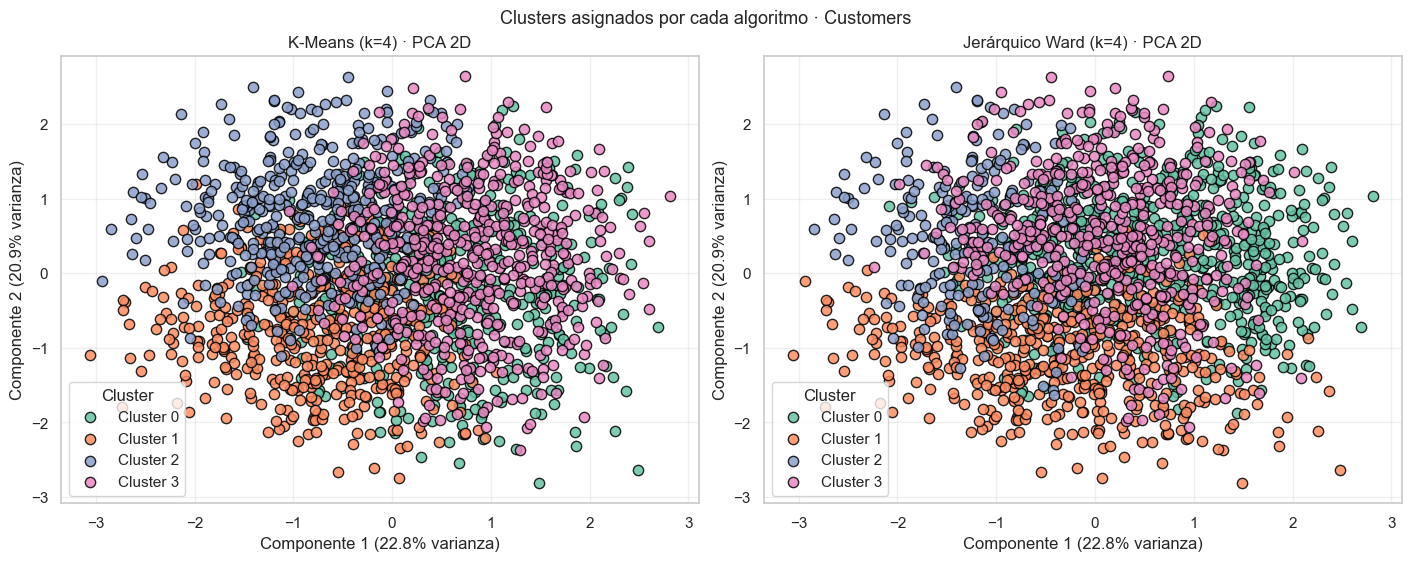

In [80]:
# Dispersión PCA: K-Means vs Clustering Jerárquico
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

for ax, (lab, titulo) in zip(axes, [(etiquetas, f'K-Means (k={K_OPT})'),
                                    (grupos, f'Jerárquico Ward (k={K_HIER})')]):
    for c in sorted(np.unique(lab)):
        m = lab == c
        ax.scatter(componentes[m, 0], componentes[m, 1], s=55, label=f'Cluster {c}',
                   edgecolor='k', alpha=0.85)
    ax.set_title(f'{titulo} · PCA 2D')
    ax.set_xlabel(f'Componente 1 ({var_exp[0]:.1f}% varianza)')
    ax.set_ylabel(f'Componente 2 ({var_exp[1]:.1f}% varianza)')
    ax.legend(title='Cluster')
    ax.grid(alpha=0.3)

fig.suptitle('Clusters asignados por cada algoritmo · Customers', fontsize=13)
plt.show()

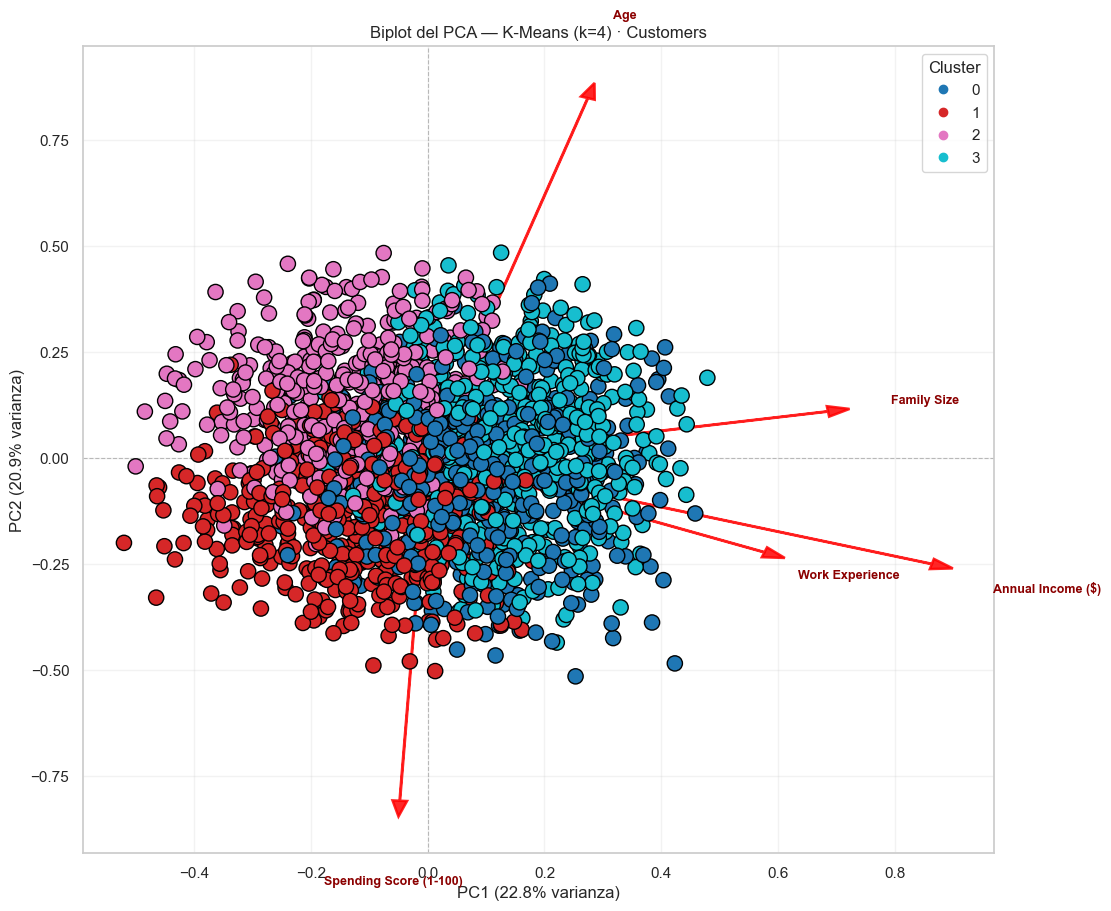

In [81]:
# Biplot del PCA: observaciones (clusters) + variables — bloque 15 del notebook Clase 8 - Kmeans.ipynb
fig, _ = biplot_pca(
    pd.DataFrame(X, columns=FEATURES),
    etiquetas,
    random_state=SEED,
    figsize=(11, 9),
    titulo=f'Biplot del PCA — K-Means (k={K_OPT}) · Customers',
    nombre_obs=[''] * len(X),
)
plt.show()

### Interpretación

Las dos primeras componentes explican en conjunto solo el **43.7 %** de la varianza (PC1 22.8 %,
PC2 20.9 %). Es un valor bajo y tiene una consecuencia directa: la nube de puntos en 2D **no puede
mostrar la separación real** entre clusters, porque más de la mitad de la información queda en las
componentes no representadas. Un solapamiento visual en este gráfico no significa que los clusters
sean idénticos en el espacio original de 5 dimensiones.

Que la varianza esté tan repartida entre componentes es en sí mismo un resultado: significa que las
cinco variables son **poco redundantes entre sí** y que no existe un eje dominante que ordene a los
clientes. Coincide con el diagnóstico del codo suave.

Comparando ambos paneles, K-Means dibuja fronteras rectas y regiones de tamaño similar, mientras Ward
produce grupos de tamaño desigual que siguen la densidad de los datos. La concordancia entre ambas
particiones es **baja (ARI ≈ 0.25)**: coinciden en la existencia de un grupo de alto gasto, pero
difieren en cómo reparten al resto de los clientes. Con estructura difusa, la partición depende
sensiblemente del algoritmo elegido.

En el biplot, las flechas de las variables apuntan en direcciones muy separadas, confirmando la baja
redundancia. Las que más contribuyen al plano son `Annual Income ($)` (que domina PC1, loading 0.72) y
`Age` (que domina PC2, loading 0.71); `Spending Score` se opone a la edad sobre PC2 (−0.68). Las dos
componentes reparten así los clientes por ingreso y por edad, y no por una única dimensión de "valor
del cliente".

## 8. Conclusiones

1. **Preprocesamiento.** El dataset llegó limpio: sin nulos en las variables usadas y sin atípicos
   extremos por 3×IQR. La estandarización fue el paso decisivo, ya que el ingreso anual (hasta
   189 974) habría dominado la distancia euclídea frente al tamaño familiar (1 a 9).

2. **Número de clusters.** El codo de Jambú desciende suavemente, sin quiebre nítido, y la silueta
   maximiza en el extremo del rango (k = 10). Ambos indicios apuntan a que **el dataset no tiene
   grupos naturalmente separados**. Se adoptó k = 4 por el codo visual y por interpretabilidad
   comercial, asumiendo explícitamente que es una partición útil más que una estructura descubierta.

3. **K-Means.** Produjo cuatro segmentos de tamaño equilibrado (468–551) separados sobre todo por
   gasto, tamaño familiar y experiencia laboral: alto gasto, bajo gasto, familia numerosa con ingreso
   alto, y trayectoria laboral larga.

4. **Clustering jerárquico.** Ward fue el enlace más adecuado: `single` mostró el efecto cadena
   esperado y `complete`/`average` quedaron en posiciones intermedias. El dendrograma con líneas de
   corte validó k = 4 mediante el salto de altura entre 4 y 3 clusters (32.53 → 38.88). Ward incorporó
   la **edad** como criterio de separación, algo que K-Means no capturó.

5. **Comparación.** La concordancia entre ambos algoritmos es baja (ARI ≈ 0.25) y las componentes
   principales solo explican el 43.7 % de la varianza. La conclusión honesta es que las fronteras
   entre segmentos de clientes son **difusas**: la segmentación resultante es una herramienta de
   negocio válida, pero no la recuperación de grupos preexistentes en los datos.